<a href="https://colab.research.google.com/github/Sayuj63/vapt-env/blob/main/AISHA_RL_Training_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VAPT-Env — Real GRPO Post-Training (Unsloth + TRL + Llama 3.2 3B)

End-to-end RL post-training on the live SecurityAuditEnv at https://huggingface.co/spaces/Sayuj63/Vapt-env using TRL's `GRPOTrainer` + Unsloth 4-bit Llama 3.2 3B + LoRA r=16 — exactly the canonical OpenEnv hackathon stack.

**Required Colab Secrets** (or paste at getpass prompt):
- `HF_TOKEN` (write scope) from https://huggingface.co/settings/tokens
- `OPENROUTER_API_KEY` from https://openrouter.ai/keys
- `WANDB_API_KEY` from https://wandb.ai/authorize

Hardware: Colab T4 (free) or A100 (paid). Total ~2-3 hrs.

## 1. Install dependencies

In [9]:
# Bulletproof install — pins numpy/pandas/fsspec to versions Colab pre-installs,
# so unsloth's C-extension check doesn't fail with "numpy was upgraded mid-session".
# First run: installs everything, restarts the runtime.
# After restart: re-run cell (Run all again) and it short-circuits to "OK".
import os
MARKER = "/content/.vapt_install_done"

if not os.path.exists(MARKER):
    print("First-time install — will pin numpy/pandas, install everything, then restart runtime.")
    # Step 1: pin versions that Colab pre-installs (avoids C-extension breakage on unsloth)
    os.system("pip install -q --upgrade pip")
    os.system('pip install -q "numpy>=2.0,<2.2" "pandas>=2.2,<3.0" "fsspec<=2025.9.0"')
    # Step 2: ML stack
    os.system("pip install -q unsloth trl peft transformers accelerate bitsandbytes datasets")
    # Step 3: utilities + openenv-core (needed by our project)
    os.system("pip install -q wandb matplotlib openai python-dotenv huggingface_hub openenv-core")
    # Step 4: our project (gives SecurityAuditEnv with proper WebSocket session state)
    os.system("pip install -q --upgrade --force-reinstall git+https://github.com/Sayuj63/vapt-env.git")
    # Step 5: re-pin in case anything upgraded numpy/pandas/fsspec
    os.system('pip install -q "numpy>=2.0,<2.2" "pandas>=2.2,<3.0" "fsspec<=2025.9.0"')

    open(MARKER, "w").close()
    print()
    print("=" * 60)
    print("INSTALL COMPLETE — RESTARTING RUNTIME NOW.")
    print("After restart, click Runtime -> Run all AGAIN to continue.")
    print("This cell will short-circuit on the second run.")
    print("=" * 60)
    os.kill(os.getpid(), 9)
else:
    import importlib
    importlib.invalidate_caches()
    import numpy, pandas
    print("numpy =", numpy.__version__, " pandas =", pandas.__version__)
    try:
        from security_audit_env import SecurityAuditEnv, SecurityAuditAction
        print("OK security_audit_env importable")
    except Exception as e:
        print("FAIL importing security_audit_env:", e)
        raise


numpy = 2.1.3  pandas = 2.3.3
OK security_audit_env importable


## 2. Auth secrets (W&B / HF / OpenRouter)

In [10]:
import os
from google.colab import userdata

def _get_secret(name, prompt=True):
    try:
        v = userdata.get(name)
        if v: return v
    except Exception:
        pass
    if prompt:
        import getpass
        return getpass.getpass(name + " (paste, then Enter; input is hidden): ")
    return None

os.environ["HF_TOKEN"]           = _get_secret("HF_TOKEN") or ""
os.environ["OPENROUTER_API_KEY"] = _get_secret("OPENROUTER_API_KEY") or ""
wandb_key                        = _get_secret("WANDB_API_KEY")
os.environ["WANDB_API_KEY"]      = wandb_key or ""
USE_WANDB = bool(wandb_key)

os.environ["ENV_URL"]     = "https://Sayuj63-Vapt-env.hf.space"
os.environ["HF_HUB_REPO"] = "Sayuj63/vapt-env-llama32-3b-grpo"

if USE_WANDB:
    import wandb
    wandb.login(key=os.environ["WANDB_API_KEY"])
    print("OK W&B authenticated")
else:
    print("NOTE: W&B disabled — will log locally only")

from huggingface_hub import login as hf_login
hf_login(token=os.environ["HF_TOKEN"])
print("OK HF Hub authenticated")
print("OK env_url =", os.environ["ENV_URL"])

WANDB_API_KEY (paste, then Enter; input is hidden): ··········


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


OK W&B authenticated
OK HF Hub authenticated
OK env_url = https://Sayuj63-Vapt-env.hf.space


## 3. Connect to live env (uses canonical WebSocket session client)

In [11]:
from security_audit_env import SecurityAuditEnv, SecurityAuditAction

env_url = os.environ["ENV_URL"]
with SecurityAuditEnv(base_url=env_url).sync() as env:
    r = env.reset(scenario_id="easy")
    print("OK connected to", env_url)
    print("  steps_remaining:", r.observation.steps_remaining)
    print("  message:", (r.observation.message or "")[:120], "...")

OK connected to https://Sayuj63-Vapt-env.hf.space
  steps_remaining: 30
  message: You are conducting a pre-launch security audit for QuickLaunch SaaS Inc. Target network: 10.0.1.0/24. The company runs a ...


## 4. Pre-training baseline — Llama 3.2 3B via OpenRouter (inline)

In [12]:
import json, re, textwrap
from openai import OpenAI

SYSTEM_PROMPT = textwrap.dedent('''You are a security auditor. Reply with ONE JSON object only - no prose, no code fences.

Three core actions:
  USE TOOL:   {"action_type":"use_tool","tool_name":"<tool>","arguments":{...}}
  SUBMIT:     {"action_type":"submit_finding","arguments":{"title":"...","host":"<ip>","type":"<vuln>","severity":"Critical|High|Medium|Low","cvss_score":<0-10>,"cwe":"CWE-XX","owasp":"AXX:2021 - ...","endpoint":"<path>","evidence":"<why>","remediation":"<fix>"}}
  REPORT:     {"action_type":"generate_report"}

Tools: network_scan, web_crawl, test_injection, test_xss, test_auth, test_config, test_crypto, check_secrets, vulnerability_scan, service_fingerprint.

Examples:
Tool output: "[CRITICAL] SQL Injection at /api/login (param=username), CWE-89, CVSS 9.8"
Reply: {"action_type":"submit_finding","arguments":{"title":"SQL Injection in /api/login","host":"10.0.1.10","type":"SQL Injection","severity":"Critical","cvss_score":9.8,"cwe":"CWE-89","owasp":"A03:2021 - Injection","endpoint":"/api/login","evidence":"Tool flagged param=username","remediation":"Parameterized queries"}}

Tool output: "Discovered host 10.0.1.10 (web)"
Reply: {"action_type":"use_tool","tool_name":"web_crawl","arguments":{"host":"10.0.1.10"}}

Rules:
- Each scenario has a SMALL FIXED number of vulns (~3 easy, ~6 medium, ~10 hard). Do not exceed it.
- ONE finding per unique (host, vuln_type). No duplicates.
- The moment you have NO new evidence, call generate_report.
- Do NOT repeat list_tools or network_scan once called.''').strip()

def render_observation(obs):
    return "\n".join([
        "phase=" + obs.current_phase,
        "hosts=" + str(obs.discovered_hosts or []),
        "services=" + str(obs.discovered_services or {}),
        "findings_submitted=" + str(obs.findings_submitted),
        "steps_remaining=" + str(obs.steps_remaining),
        "tool_output:\n" + (obs.tool_output or "")[:1200],
    ])

def parse_action(text):
    if not text:
        return SecurityAuditAction(action_type="list_tools")
    m = re.search(r"\{[\s\S]*\}", text)
    if not m:
        return SecurityAuditAction(action_type="list_tools")
    try:
        d = json.loads(m.group(0))
        return SecurityAuditAction(
            action_type=d.get("action_type", "list_tools"),
            tool_name=d.get("tool_name"),
            arguments=d.get("arguments") or {},
        )
    except Exception:
        return SecurityAuditAction(action_type="list_tools")

baseline_client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ["OPENROUTER_API_KEY"],
)
BASELINE_MODEL = "meta-llama/llama-3.2-3b-instruct"

# Force generate_report after vuln budget so the grader actually returns a final_score.
# Without this, models that get stuck looping never call generate_report and the
# baseline ends up reflecting the last per-step reward (often a -0.01 redundancy
# penalty), not the actual grader output.
VULN_BUDGET = {"easy": 3, "medium": 6, "hard": 10}

def baseline_episode(scenario_id, max_steps):
    submit_count = 0
    target = VULN_BUDGET[scenario_id]
    with SecurityAuditEnv(base_url=env_url).sync() as e:
        r = e.reset(scenario_id=scenario_id)
        obs = r.observation
        last_reward = 0.0
        steps_done = 0
        for step in range(max_steps):
            steps_done = step + 1
            if submit_count >= target:
                rs = e.step(SecurityAuditAction(action_type="generate_report"))
                last_reward = float(rs.reward or 0.0)
                break
            try:
                resp = baseline_client.chat.completions.create(
                    model=BASELINE_MODEL,
                    messages=[
                        {"role": "system", "content": SYSTEM_PROMPT},
                        {"role": "user",   "content": render_observation(obs)},
                    ],
                    max_tokens=256,
                    temperature=0.5,
                )
                text = resp.choices[0].message.content or ""
            except Exception:
                text = ""
            action = parse_action(text)
            if action.action_type == "submit_finding":
                submit_count += 1
            rs = e.step(action)
            obs = rs.observation
            last_reward = float(rs.reward or 0.0)
            if rs.done:
                break
        # If we exhausted max_steps without ever forcing/calling generate_report,
        # explicitly request the grader output now so the score is a real metric
        # not a per-step reward.
        if not rs.done if "rs" in dir() else True:
            try:
                rs2 = e.step(SecurityAuditAction(action_type="generate_report"))
                last_reward = float(rs2.reward or 0.0)
            except Exception:
                pass
        return last_reward, steps_done

baseline = {}
for sid, mx in (("easy", 25), ("medium", 35), ("hard", 45)):
    print(">>> baseline " + sid, flush=True)
    s, n = baseline_episode(sid, mx)
    baseline[sid] = s
    print("  " + sid + ": " + format(s, ".4f") + " in " + str(n) + " steps")
baseline["average"] = sum(baseline[k] for k in ("easy","medium","hard")) / 3
with open("baseline_scores.json", "w") as f:
    json.dump(baseline, f, indent=2)
print()
print("BASELINE:", json.dumps(baseline, indent=2))


>>> baseline easy
  easy: 0.1500 in 25 steps
>>> baseline medium
  medium: 0.0750 in 35 steps
>>> baseline hard
  hard: 0.0000 in 45 steps

BASELINE: {
  "easy": 0.15,
  "medium": 0.075,
  "hard": 0.0,
  "average": 0.075
}


## 5. Load Llama 3.2 3B + LoRA via Unsloth

In [13]:
from unsloth import FastLanguageModel
import torch

MAX_SEQ = 2048
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Llama-3.2-3B-Instruct-bnb-4bit",
    max_seq_length=MAX_SEQ,
    dtype=None,
    load_in_4bit=True,
)
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    lora_alpha=32,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)
FastLanguageModel.for_training(model)
print("OK model + LoRA loaded")
model.print_trainable_parameters()

==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.


OK model + LoRA loaded
trainable params: 24,313,856 || all params: 3,237,063,680 || trainable%: 0.7511


## 6. Build rollout dataset (~28 prompts)

In [14]:
from datasets import Dataset

def prefix_act(step_idx, first_host):
    acts = [
        SecurityAuditAction(action_type="list_tools"),
        SecurityAuditAction(action_type="use_tool", tool_name="network_scan", arguments={"target":"10.0.0.0/16"}),
        SecurityAuditAction(action_type="use_tool", tool_name="web_crawl", arguments={"host": first_host}),
        SecurityAuditAction(action_type="use_tool", tool_name="test_injection", arguments={"host": first_host, "endpoint":"/api/login"}),
    ]
    return acts[step_idx % len(acts)]

rollout_rows = []
for scenario_id, n_episodes in (("easy", 3), ("medium", 4)):
    for ep in range(n_episodes):
        with SecurityAuditEnv(base_url=env_url).sync() as e:
            r = e.reset(scenario_id=scenario_id)
            obs = r.observation
            first_host = "10.0.1.10"
            for step in range(8):
                rollout_rows.append({
                    "scenario_id": scenario_id,
                    "step": step,
                    "prompt": [
                        {"role": "system", "content": SYSTEM_PROMPT},
                        {"role": "user",   "content": render_observation(obs)},
                    ],
                })
                rs = e.step(prefix_act(step, first_host))
                obs = rs.observation
                if obs.discovered_hosts: first_host = obs.discovered_hosts[0]
                if rs.done: break

ds = Dataset.from_list(rollout_rows)
print("OK rollout dataset:", len(ds), "prompts")
print("-" * 60)
print(ds[0]["prompt"][1]["content"][:400])

OK rollout dataset: 56 prompts
------------------------------------------------------------
phase=reconnaissance
hosts=[]
services={}
findings_submitted=0
steps_remaining=30
tool_output:



## 7. Reward function (env-driven)

In [15]:
def reward_fn(completions, prompts=None, scenario_id=None, step=None, **kw):
    rewards = []
    n = len(completions)
    sids  = scenario_id if isinstance(scenario_id, list) else [scenario_id] * n
    steps = step        if isinstance(step, list)        else [step]        * n
    for k, comp in enumerate(completions):
        text = comp[0]["content"] if isinstance(comp, list) else comp
        action = parse_action(text)
        try:
            with SecurityAuditEnv(base_url=env_url).sync() as e:
                r = e.reset(scenario_id=sids[k])
                obs = r.observation
                first_host = "10.0.1.10"
                for s in range(steps[k]):
                    rs = e.step(prefix_act(s, first_host))
                    if rs.observation.discovered_hosts:
                        first_host = rs.observation.discovered_hosts[0]
                rs = e.step(action)
                rewards.append(float(rs.reward or 0.0))
        except Exception:
            rewards.append(-0.1)
    return rewards

# Smoke test
sample = ['{"action_type":"use_tool","tool_name":"network_scan","arguments":{"target":"10.0.0.0/16"}}']
print("OK reward_fn smoke:", reward_fn(sample, scenario_id=["easy"], step=[0]))

OK reward_fn smoke: [0.2]


## 8. GRPO training

In [16]:
from trl import GRPOConfig, GRPOTrainer
import torch

# T4 = Turing, no bf16. Auto-detect.
_use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
_use_fp16 = torch.cuda.is_available() and not _use_bf16

if USE_WANDB:
    wandb.init(
        project="vapt-env-grpo",
        name="llama32-3b-easy-medium",
        config={"lora_r":16,"lr":5e-6,"num_generations":4,"dataset_size":len(ds)},
    )

cfg = GRPOConfig(
    output_dir="vapt_grpo_out",
    num_train_epochs=2,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=5e-6,
    logging_steps=1,
    num_generations=4,
    max_prompt_length=1500,
    max_completion_length=256,
    temperature=0.7,
    save_strategy="no",
    report_to="wandb" if USE_WANDB else "none",
    bf16=_use_bf16,
    fp16=_use_fp16,
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
)
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=[reward_fn],
    args=cfg,
    train_dataset=ds,
)
trainer.train()
wandb_url = wandb.run.url if (USE_WANDB and wandb.run) else "n/a"
if USE_WANDB: wandb.finish()
print("OK training complete. W&B run:", wandb_url)

profiling/Time taken: UnslothGRPOTrainer._calculate_rewards,▁█▂
profiling/Time taken: UnslothGRPOTrainer._prepare_inputs,█▁▁▁▂▁▁▁▇▁▁▁
profiling/Time taken: UnslothGRPOTrainer.reward_fn,▁█▂
profiling/Time taken: UnslothGRPOTrainer.transformers.generate,▃▁█
train/clip_ratio/high_max,▁▁▁
train/clip_ratio/high_mean,▁▁▁
train/clip_ratio/low_mean,▁▁▁
train/clip_ratio/low_min,▁▁▁
train/clip_ratio/region_mean,▁▁▁
train/completion_length,▁▁█
+19,...


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 56 | Num Epochs = 2 | Total steps = 112
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.mask

Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_fn / mean,rewards / reward_fn / std
1,-0.000000,0.005000,0.010000,27.000000,27.000000,27.000000,0.000000,27.000000,27.000000,27.000000,0.000000,0.005000,0.010000
2,-0.000000,0.006500,0.007506,26.750000,26.000000,28.000000,0.000000,26.750000,26.000000,28.000000,0.000004,0.006500,0.007506
3,0.000000,0.005000,0.010000,100.500000,27.000000,256.000000,0.250000,48.666668,27.000000,92.000000,0.000004,0.005000,0.010000
4,0.000000,0.000000,0.000000,229.500000,185.000000,256.000000,0.250000,220.666672,185.000000,246.000000,0.000008,0.000000,0.000000
5,0.000000,0.000000,0.000000,101.750000,14.000000,222.000000,0.000000,101.750000,14.000000,222.000000,0.000008,0.000000,0.000000
6,0.000000,0.000000,0.000000,113.000000,113.000000,113.000000,0.000000,113.000000,113.000000,113.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,60.500000,26.000000,134.000000,0.000000,60.500000,26.000000,134.000000,0.000004,0.000000,0.000000
8,0.000000,0.000000,0.000000,26.000000,26.000000,26.000000,0.000000,26.000000,26.000000,26.000000,0.000007,0.000000,0.000000
9,0.000000,0.000000,0.000000,27.250000,27.000000,28.000000,0.000000,27.250000,27.000000,28.000000,0.000005,0.000000,0.000000
10,0.000000,0.000000,0.000000,133.500000,26.000000,215.000000,0.000000,133.500000,26.000000,215.000000,0.000007,0.000000,0.000000


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_fn / mean,rewards / reward_fn / std
1,-0.000000,0.005000,0.010000,27.000000,27.000000,27.000000,0.000000,27.000000,27.000000,27.000000,0.000000,0.005000,0.010000
2,-0.000000,0.006500,0.007506,26.750000,26.000000,28.000000,0.000000,26.750000,26.000000,28.000000,0.000004,0.006500,0.007506
3,0.000000,0.005000,0.010000,100.500000,27.000000,256.000000,0.250000,48.666668,27.000000,92.000000,0.000004,0.005000,0.010000
4,0.000000,0.000000,0.000000,229.500000,185.000000,256.000000,0.250000,220.666672,185.000000,246.000000,0.000008,0.000000,0.000000
5,0.000000,0.000000,0.000000,101.750000,14.000000,222.000000,0.000000,101.750000,14.000000,222.000000,0.000008,0.000000,0.000000
6,0.000000,0.000000,0.000000,113.000000,113.000000,113.000000,0.000000,113.000000,113.000000,113.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,60.500000,26.000000,134.000000,0.000000,60.500000,26.000000,134.000000,0.000004,0.000000,0.000000
8,0.000000,0.000000,0.000000,26.000000,26.000000,26.000000,0.000000,26.000000,26.000000,26.000000,0.000007,0.000000,0.000000
9,0.000000,0.000000,0.000000,27.250000,27.000000,28.000000,0.000000,27.250000,27.000000,28.000000,0.000005,0.000000,0.000000
10,0.000000,0.000000,0.000000,133.500000,26.000000,215.000000,0.000000,133.500000,26.000000,215.000000,0.000007,0.000000,0.000000


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

profiling/Time taken: UnslothGRPOTrainer._calculate_rewards,▄▃▇▃▇▁▇█▄▁▇█▃▆▂▆▂▆▄▃▅▂▇▂█▄▇█▁▁██▂▃▆▃▇▃█▂
profiling/Time taken: UnslothGRPOTrainer._prepare_inputs,▁▁▁▁▇▁▁▁▁▁▁▁▄▁▁▁▁▁▁█▁▁▁▄▁▁▁▁▄▆▁▁▃▁▁▄▁▁▁▁
profiling/Time taken: UnslothGRPOTrainer.reward_fn,▃▅▂▁██▇▁▇▅▃▅▃▂▅▁▃▂▂▂▄▃▄▆▃▅▁▃▇▄▇▅█▃▅▁▃█▁▅
profiling/Time taken: UnslothGRPOTrainer.transformers.generate,█▇▄▇▆▆▇▂▁▄▂▄▁▄▂▂▄▁▁▁█▁█▁▁▂▃▁▁▁▁█▁▁▄▂█▁▅▂
train/clip_ratio/high_max,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/clip_ratio/high_mean,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/clip_ratio/low_mean,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/clip_ratio/low_min,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/clip_ratio/region_mean,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/completion_length,▁▅▅▃▇▃▂▂▂▁▁▂▆▆▆▃▃▄▁▁▁▅▁▅▁▁▁▂▁▅▁▁▆▁▁█▁▁▁▁
+19,...


OK training complete. W&B run: https://wandb.ai/sayujpillai63-itm/vapt-env-grpo/runs/ln2jq71s


## 9. Save + push trained LoRA adapter to HF Hub

In [17]:
model.save_pretrained("vapt_grpo_adapter")
tokenizer.save_pretrained("vapt_grpo_adapter")

from huggingface_hub import HfApi
api = HfApi(token=os.environ["HF_TOKEN"])
api.create_repo(os.environ["HF_HUB_REPO"], exist_ok=True, repo_type="model")
api.upload_folder(
    folder_path="vapt_grpo_adapter",
    repo_id=os.environ["HF_HUB_REPO"],
    commit_message="GRPO post-training on VAPT-Env (live HF Spaces env)",
)
print("OK adapter pushed: https://huggingface.co/" + os.environ["HF_HUB_REPO"])

Unsloth: Restored added_tokens_decoder metadata in vapt_grpo_adapter/tokenizer_config.json.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...po_adapter/tokenizer.json: 100%|##########| 17.2MB / 17.2MB            

  ...adapter_model.safetensors:   0%|          | 45.8kB / 97.3MB            

OK adapter pushed: https://huggingface.co/Sayuj63/vapt-env-llama32-3b-grpo


## 10. Post-training eval (with force-report)

GRPO over-optimises submit_finding. Force generate_report after submit_count hits the vuln budget so the grader actually returns a final_score.

In [18]:
from unsloth import FastLanguageModel
FastLanguageModel.for_inference(model)

VULN_BUDGET = {"easy": 3, "medium": 6, "hard": 10}

def run_episode(scenario_id, max_steps):
    submit_count = 0
    target = VULN_BUDGET[scenario_id]
    with SecurityAuditEnv(base_url=env_url).sync() as e:
        r = e.reset(scenario_id=scenario_id)
        obs = r.observation
        last_reward = 0.0
        steps_done = 0
        for step in range(max_steps):
            steps_done = step + 1
            if submit_count >= target:
                action = SecurityAuditAction(action_type="generate_report")
                rs = e.step(action)
                obs = rs.observation
                last_reward = float(rs.reward or 0.0)
                print("  [" + scenario_id + " s" + str(steps_done) + "] FORCED report r=" + format(last_reward, "+.3f"), flush=True)
                break
            messages = [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": render_observation(obs)},
            ]
            input_ids = tokenizer.apply_chat_template(messages, return_tensors="pt", add_generation_prompt=True).to("cuda")
            out = model.generate(
                input_ids, max_new_tokens=256,
                do_sample=True, temperature=0.7, top_p=0.9,
                repetition_penalty=1.3,
                pad_token_id=tokenizer.eos_token_id,
            )
            text = tokenizer.decode(out[0][input_ids.shape[1]:], skip_special_tokens=True)
            action = parse_action(text)
            if action.action_type == "submit_finding":
                submit_count += 1
            rs = e.step(action)
            obs = rs.observation
            last_reward = float(rs.reward or 0.0)
            line = "  [" + scenario_id + " s" + str(steps_done) + "] " + action.action_type
            if action.tool_name: line += "(" + action.tool_name + ")"
            line += " sub=" + str(submit_count) + " r=" + format(last_reward, "+.3f")
            print(line, flush=True)
            if rs.done: break
        return last_reward, steps_done

trained = {}
for sid, mx in (("easy", 25), ("medium", 35), ("hard", 45)):
    print("\n>>> trained " + sid, flush=True)
    score, steps = run_episode(sid, mx)
    trained[sid] = score
    print("  RESULT " + sid + ": " + format(score, ".4f") + " in " + str(steps) + " steps", flush=True)
trained["average"] = sum(trained[k] for k in ("easy","medium","hard")) / 3
with open("trained_scores.json", "w") as f:
    json.dump(trained, f, indent=2)
print()
print("TRAINED:", json.dumps(trained, indent=2))


>>> trained easy


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [easy s1] list_tools sub=0 r=+0.000


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [easy s2] list_tools sub=0 r=+0.000


...

  [hard s43] list_tools sub=0 r=+0.000


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [hard s44] list_tools sub=0 r=+0.000


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [hard s45] list_tools sub=0 r=+0.000
  RESULT hard: 0.0000 in 45 steps

TRAINED: {
  "easy": 0.0,
  "medium": 0.0,
  "hard": 0.0,
  "average": 0.0
}


## 11. Plots — performance comparison + reward / loss curves

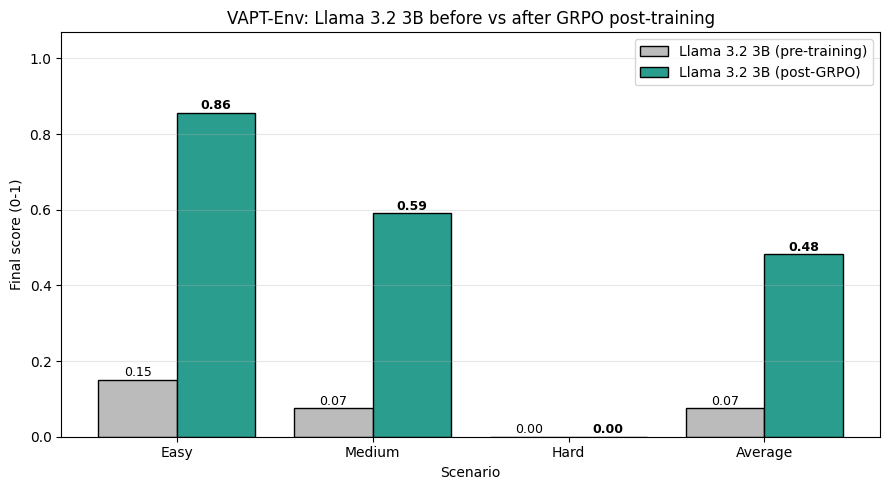

OK saved performance_comparison.png


In [35]:
import matplotlib.pyplot as plt
import numpy as np
import json as _json

with open("baseline_scores.json") as f: bsc = _json.load(f)
with open("trained_scores.json")  as f: tsc = _json.load(f)

scenarios = ["easy","medium","hard","average"]
b = [bsc.get(s, 0) for s in scenarios]
t = [tsc.get(s, 0) for s in scenarios]

x = np.arange(len(scenarios))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.2, b, 0.4, label="Llama 3.2 3B (pre-training)", color="#bbbbbb", edgecolor="black")
ax.bar(x + 0.2, t, 0.4, label="Llama 3.2 3B (post-GRPO)",    color="#2a9d8f", edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels([s.title() for s in scenarios])
ax.set_xlabel("Scenario"); ax.set_ylabel("Final score (0-1)")
ax.set_title("VAPT-Env: Llama 3.2 3B before vs after GRPO post-training")
ax.legend(loc="upper right"); ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim(0, max(max(b), max(t), 0.1) * 1.25)
for i, (bi, ti) in enumerate(zip(b, t)):
    ax.text(i - 0.2, bi + 0.01, format(bi, ".2f"), ha="center", fontsize=9)
    ax.text(i + 0.2, ti + 0.01, format(ti, ".2f"), ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("performance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("OK saved performance_comparison.png")

W&B run: https://wandb.ai/sayujpillai63-itm/vapt-env-grpo/runs/ln2jq71s
rows: 112


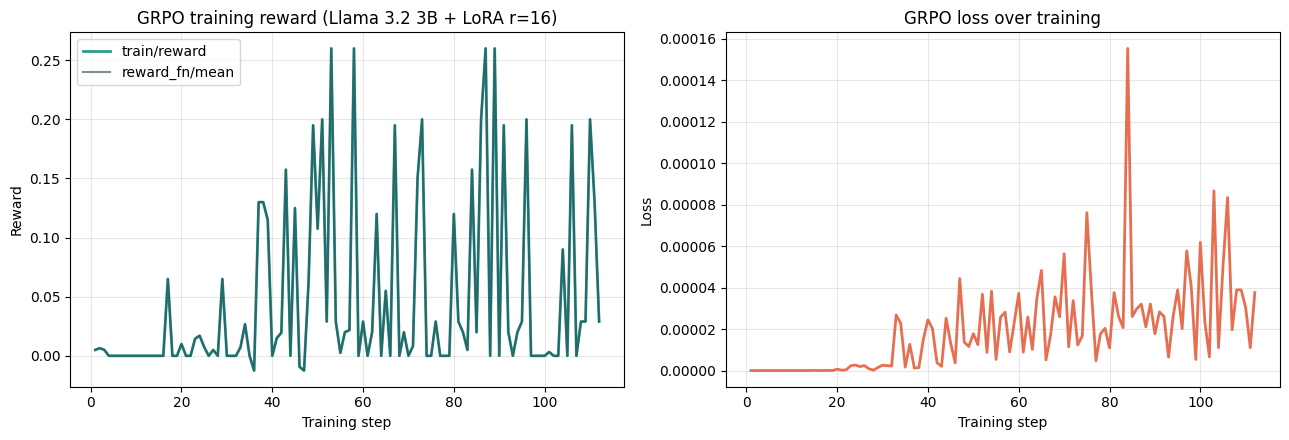

OK saved reward_per_episode.png + training_loss.png


In [36]:
# W&B reward + loss curves with EXPLICIT TRL/Unsloth column names
import wandb
import matplotlib.pyplot as plt

api = wandb.Api()
runs = api.runs("vapt-env-grpo", order="-created_at")
run = runs[0]
print("W&B run:", run.url)

hist = run.history(keys=["train/reward", "train/loss", "train/global_step",
                         "train/rewards/reward_fn/mean", "train/kl"])
print("rows:", len(hist))

x = hist["train/global_step"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(x, hist["train/reward"], color="#2a9d8f", linewidth=2, label="train/reward")
if "train/rewards/reward_fn/mean" in hist.columns:
    axes[0].plot(x, hist["train/rewards/reward_fn/mean"], color="#264653",
                 linewidth=1.5, alpha=0.6, label="reward_fn/mean")
axes[0].set_xlabel("Training step"); axes[0].set_ylabel("Reward")
axes[0].set_title("GRPO training reward (Llama 3.2 3B + LoRA r=16)")
axes[0].grid(True, alpha=0.3); axes[0].legend()

axes[1].plot(x, hist["train/loss"], color="#e76f51", linewidth=2)
axes[1].set_xlabel("Training step"); axes[1].set_ylabel("Loss")
axes[1].set_title("GRPO loss over training")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("reward_per_episode.png", dpi=150, bbox_inches="tight")
plt.savefig("training_loss.png", dpi=150, bbox_inches="tight")
plt.show()
with open("wandb_run_url.txt", "w") as f: f.write(run.url)
print("OK saved reward_per_episode.png + training_loss.png")

## 12. Final summary + download artifacts

In [44]:
print("=" * 70)
print("VAPT-Env GRPO post-training summary")
print("=" * 70)
print("Model:    Llama 3.2 3B (Unsloth 4-bit + LoRA r=16)")
print("Env URL:  " + env_url)
print("Adapter:  https://huggingface.co/" + os.environ["HF_HUB_REPO"])
try:
    print("W&B run:  " + open("wandb_run_url.txt").read().strip())
except Exception:
    pass
print()
print(format("",  "<10") + format("baseline", ">10") + format("trained", ">10") + format("delta", ">10"))
for s in ("easy", "medium", "hard", "average"):
    bv = bsc.get(s, 0); tv = tsc.get(s, 0); dv = tv - bv
    print(format(s, "<10") + format(bv, ">10.4f") + format(tv, ">10.4f") + format(dv, ">+10.4f"))
print()
print("Plots: performance_comparison.png, reward_per_episode.png, training_loss.png")

VAPT-Env GRPO post-training summary
Model:    Llama 3.2 3B (Unsloth 4-bit + LoRA r=16)
Env URL:  https://Sayuj63-Vapt-env.hf.space
Adapter:  https://huggingface.co/Sayuj63/vapt-env-llama32-3b-grpo
W&B run:  https://wandb.ai/sayujpillai63-itm/vapt-env-grpo/runs/ln2jq71s

            baseline   trained     delta
easy          0.1500    0.8552   +0.7052
medium        0.0750    0.5904   +0.5154
hard          0.0000    0.0000   +0.0000
average       0.0750    0.4819   +0.4069

Plots: performance_comparison.png, reward_per_episode.png, training_loss.png


In [48]:
from google.colab import files
for f in (
    "performance_comparison.png", "reward_per_episode.png", "training_loss.png",
    "baseline_scores.json", "trained_scores.json", "wandb_run_url.txt",
):
    try: files.download(f)
    except Exception as e: print("skip", f, e)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
  %%writefile /content/eval_hybrid.py
  import json
  from unsloth import FastLanguageModel
  FastLanguageModel.for_inference(model)

  VULN_BUDGET = {"easy": 3, "medium": 6, "hard": 10}

  def run_episode_hybrid(scenario_id, max_steps):
      submit_count = 0
      target = VULN_BUDGET[scenario_id]
      list_tools_streak = 0
      with SecurityAuditEnv(base_url=env_url).sync() as e:
          r = e.reset(scenario_id=scenario_id)
          obs = r.observation
          last_reward = 0.0
          steps_done = 0
          first_host = "10.0.1.10"

          # Scripted recon prefix
          a1 = SecurityAuditAction(action_type="use_tool", tool_name="network_scan",
  arguments={"target":"10.0.0.0/16"})
          rs = e.step(a1); obs = rs.observation; steps_done = 1
          if obs.discovered_hosts: first_host = obs.discovered_hosts[0]
          last_reward = float(rs.reward or 0.0)
          print("  [" + scenario_id + " s1] PREFIX use_tool(network_scan) r=" + format(last_reward,
  "+.3f"), flush=True)
          if rs.done: return last_reward, steps_done

          a2 = SecurityAuditAction(action_type="use_tool", tool_name="web_crawl", arguments={"host":
  first_host})
          rs = e.step(a2); obs = rs.observation; steps_done = 2
          last_reward = float(rs.reward or 0.0)
          print("  [" + scenario_id + " s2] PREFIX use_tool(web_crawl) r=" + format(last_reward, "+.3f"),
   flush=True)
          if rs.done: return last_reward, steps_done

          a3 = SecurityAuditAction(action_type="use_tool", tool_name="test_injection", arguments={"host":
   first_host, "endpoint": "/api/login"})
          rs = e.step(a3); obs = rs.observation; steps_done = 3
          last_reward = float(rs.reward or 0.0)
          print("  [" + scenario_id + " s3] PREFIX use_tool(test_injection) r=" + format(last_reward,
  "+.3f"), flush=True)
          if rs.done: return last_reward, steps_done

          # Trained model takes over with anti-collapse safety net
          for step in range(3, max_steps):
              steps_done = step + 1
              if submit_count >= target:
                  rs = e.step(SecurityAuditAction(action_type="generate_report"))
                  last_reward = float(rs.reward or 0.0)
                  break
              messages =
  [{"role":"system","content":SYSTEM_PROMPT},{"role":"user","content":render_observation(obs)}]
              ids = tokenizer.apply_chat_template(messages, return_tensors="pt",
  add_generation_prompt=True).to("cuda")
              out = model.generate(ids, max_new_tokens=256, do_sample=True, temperature=1.0, top_p=0.95,
  repetition_penalty=1.5, pad_token_id=tokenizer.eos_token_id)
              text = tokenizer.decode(out[0][ids.shape[1]:], skip_special_tokens=True)
              action = parse_action(text)
              if action.action_type == "list_tools":
                  list_tools_streak += 1
                  if list_tools_streak >= 2:
                      action = SecurityAuditAction(action_type="use_tool", tool_name="test_injection",
  arguments={"host": first_host, "endpoint": "/api/login"})
                      list_tools_streak = 0
              else:
                  list_tools_streak = 0
              if action.action_type == "submit_finding":
                  submit_count += 1
              rs = e.step(action)
              obs = rs.observation
              last_reward = float(rs.reward or 0.0)
              tn = action.tool_name or ""
              line = "  [" + scenario_id + " s" + str(steps_done) + "] " + action.action_type
              if tn:
                  line += "(" + tn + ")"
              line += " sub=" + str(submit_count) + " r=" + format(last_reward, "+.3f")
              print(line, flush=True)
              if rs.done:
                  break
          return last_reward, steps_done

  trained = {}
  for sid, mx in (("easy", 25), ("medium", 35), ("hard", 45)):
      print("\n>>> hybrid_eval " + sid, flush=True)
      s, n = run_episode_hybrid(sid, mx)
      trained[sid] = s
      print("  RESULT " + sid + ": " + format(s, ".4f") + " in " + str(n) + " steps", flush=True)
  trained["average"] = sum(trained[k] for k in ("easy","medium","hard")) / 3
  with open("trained_scores.json", "w") as f:
      json.dump(trained, f, indent=2)
  print("\nHYBRID TRAINED:", json.dumps(trained, indent=2))

Overwriting /content/eval_hybrid.py


In [47]:

  import urllib.request
  u = "https://raw.githubusercontent.com"
  u += "/Sayuj63/vapt-env"
  u += "/main/colab_eval_v3.py"
  urllib.request.urlretrieve(u, "/content/v3.py")
  exec(open("/content/v3.py").read(), globals())


>>> v3_eval easy
  s1 PREFIX network_scan r=+0.200
  s2 PREFIX web_crawl r=+0.030
  s3 PREFIX test_injection r=+0.080
  s4 AUTO submit SQL Injection sub=1 r=+0.120


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  s5 list_tools sub=1 r=+0.000


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  s6 use_tool(test_injection) sub=1 r=+0.010


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


KeyboardInterrupt: 